# Netflix Movie Recommendation System

## CRISP-DM Framework

### Project Overview

Netflix hosts thousands of movies, making it difficult for users to quickly discover content they are likely to enjoy. As a result, users may spend excessive time browsing, leading to reduced engagement and satisfaction.

This project develops and evaluates three recommendation approaches to improve movie discovery:

- **Popularity-Based Recommendation** – recommends highly rated and popular movies.
- **Content-Based Recommendation** – recommends movies with similar characteristics.
- **Collaborative Filtering** – recommends movies based on user rating behavior.

The project follows the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology to ensure a structured and business-oriented data science workflow.

# 1. Business Understanding

## Business Problem

Netflix users are presented with a large catalogue of movies, making it challenging to identify content that matches their interests. Ineffective recommendations may increase browsing time and reduce user engagement.

## Project Objectives

The main objective is to build a movie recommendation system capable of suggesting relevant movies using different recommendation strategies.

Specifically, this project aims to:

- Understand and prepare the MovieLens dataset.
- Explore movie and user rating patterns.
- Develop popularity-based, content-based, and collaborative filtering recommendation models.
- Compare the performance of the different approaches.
- Recommend the most suitable approach for deployment.

## CRISP-DM Methodology

This project follows the six phases of the CRISP-DM framework:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Modelling
6. Evaluation and Business Recommendations

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import ast
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import missingno as msno

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Data Understanding

## Dataset Description

This project uses the **MovieLens Movies Dataset**, which combines movie metadata from TMDB with user ratings from the MovieLens project.

The following files are used throughout the analysis:

| Dataset | Description |
|----------|-------------|
| `movies_metadata.csv` | Movie information such as title, genres, release date, popularity, revenue and ratings. |
| `ratings_small.csv` | User ratings for movies. |
| `credits.csv` | Cast and crew information. |
| `keywords.csv` | Movie plot keywords. |
| `links_small.csv` | Mapping between MovieLens IDs and TMDB IDs. |

Together, these datasets provide the information required to build popularity-based, content-based and collaborative filtering recommendation systems.

In [3]:
# Load datasets

movies = pd.read_csv("movies_metadata.csv", low_memory=False)
ratings = pd.read_csv("ratings_small.csv")
credits = pd.read_csv("credits.csv")
keywords = pd.read_csv("keywords.csv")
links = pd.read_csv("links_small.csv")

datasets = {
    "Movies": movies,
    "Ratings": ratings,
    "Credits": credits,
    "Keywords": keywords,
    "Links": links
}

print("Datasets Loaded Successfully.\n")

for name, df in datasets.items():
    print(f"{name:<12} Shape: {df.shape}")

Datasets Loaded Successfully.

Movies       Shape: (45466, 24)
Ratings      Shape: (100004, 4)
Credits      Shape: (45476, 3)
Keywords     Shape: (46419, 2)
Links        Shape: (9125, 3)


In [4]:
# Display the first few records of each dataset

for name, df in datasets.items():

    print("="*80)
    print(name.upper())
    print("="*80)

    display(df.head(3))

MOVIES


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg',...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear o...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an enchanted board game that opens the door to a magical w...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Inters...","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0


RATINGS


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182


CREDITS


,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)', 'credit_id': '52fe4284c3a36847f8024f95', 'gender'...","[{'credit_id': '52fe4284c3a36847f8024f49', 'department': 'Directing', 'gender': 2, 'id': 7879, '...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', 'credit_id': '52fe44bfc3a36847f80a7c73', 'gender': ...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'department': 'Production', 'gender': 2, 'id': 511, '...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'credit_id': '52fe466a9251416c75077a8d', 'gender': 2...","[{'credit_id': '52fe466a9251416c75077a89', 'department': 'Directing', 'gender': 2, 'id': 26502, ...",15602


KEYWORDS


,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 10941, 'name': 'disappearance'}, {'id': 15101, 'nam..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392, 'name': 'best friend'}, {'id': 179431, 'name': '..."


LINKS


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


In [5]:
# Dataset summary

summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
}, index=datasets.keys())

summary

,Rows,Columns,Missing Values,Duplicate Rows
Movies,45466,24,105562,17
Ratings,100004,4,0,0
Credits,45476,3,0,37
Keywords,46419,2,0,987
Links,9125,3,13,0


In [6]:
# Missing values by dataset

for name, df in datasets.items():

    missing = (
        df.isnull()
          .sum()
          .sort_values(ascending=False)
    )

    missing = missing[missing > 0]

    if len(missing):

        print(f"\n{name}")

        display(
            missing.to_frame("Missing Values")
        )


Movies


,Missing Values
belongs_to_collection,40972
homepage,37684
tagline,25054
overview,954
poster_path,386
runtime,263
status,87
release_date,87
imdb_id,17
original_language,11



Links


,Missing Values
tmdbId,13


### Key Findings

- Five datasets were successfully loaded and will be integrated during the modelling phase.
- The movie metadata dataset contains the largest number of observations and includes rich descriptive information useful for content-based recommendation.
- The ratings dataset contains user–movie interactions required for collaborative filtering.
- Missing values are primarily concentrated in metadata fields and will be addressed during data preparation.
- The `links_small.csv` dataset provides the mapping between MovieLens and TMDB identifiers, enabling integration of ratings with movie metadata.

# 3. Data Preparation

The objective of this phase is to clean, transform and integrate the datasets to create a consistent dataset suitable for recommendation modelling.

The main tasks include:

- Cleaning missing and inconsistent values.
- Correcting data types.
- Parsing nested JSON columns.
- Engineering new features.
- Merging datasets to create a unified movie dataset.

In [7]:
# Check dataset quality

summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Missing": [df.isnull().sum().sum() for df in datasets.values()],
    "Duplicates": [df.duplicated().sum() for df in datasets.values()]
}, index=datasets.keys())

summary

,Rows,Missing,Duplicates
Movies,45466,105562,17
Ratings,100004,0,0
Credits,45476,0,37
Keywords,46419,0,987
Links,9125,13,0


In [8]:
# Remove duplicate rows

movies.drop_duplicates(inplace=True)
credits.drop_duplicates(inplace=True)
keywords.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

print("Duplicates removed.")

Duplicates removed.


In [9]:
# Keep only useful columns

movies = movies[
    [
        "id",
        "title",
        "overview",
        "genres",
        "release_date",
        "vote_average",
        "vote_count",
        "popularity",
        "belongs_to_collection"
    ]
].copy()

In [10]:
# Convert IDs and release dates

movies["id"] = pd.to_numeric(
    movies["id"],
    errors="coerce"
)

movies.dropna(subset=["id"], inplace=True)

movies["id"] = movies["id"].astype(int)

movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    errors="coerce"
)

movies["release_year"] = movies["release_date"].dt.year

In [11]:
# Fill missing values

movies["overview"] = movies["overview"].fillna("")
movies["belongs_to_collection"] = movies["belongs_to_collection"].fillna("None")

### Parsing Nested JSON Columns

The `genres`, `credits`, and `keywords` datasets store information as stringified JSON objects.

These fields are converted into structured Python objects so that important attributes such as genres, cast members, directors and keywords can be extracted for content-based recommendation.

In [13]:
# Helper function for parsing JSON columns

def parse_json(text):
    try:
        return ast.literal_eval(text)
    except:
        return []

In [14]:
# Parse JSON columns

movies["genres"] = movies["genres"].apply(parse_json)
credits["cast"] = credits["cast"].apply(parse_json)
credits["crew"] = credits["crew"].apply(parse_json)
keywords["keywords"] = keywords["keywords"].apply(parse_json)

In [15]:
# Helper functions

def extract_names(items):
    if not isinstance(items, list):
        return []

    return [item["name"] for item in items]


def get_director(crew):
    if not isinstance(crew, list):
        return ""

    for person in crew:
        if person["job"] == "Director":
            return person["name"]

    return ""

In [16]:
# Extract useful features

movies["genres"] = movies["genres"].apply(extract_names)

credits["cast"] = credits["cast"].apply(lambda x: extract_names(x)[:3])

credits["director"] = credits["crew"].apply(get_director)

keywords["keywords"] = keywords["keywords"].apply(extract_names)

In [17]:
# Merge datasets

movies = movies.merge(
    credits[["id", "cast", "director"]],
    on="id",
    how="left"
)

movies = movies.merge(
    keywords,
    on="id",
    how="left"
)

print(movies.shape)
movies.head()

(45457, 13)


,id,title,overview,genres,release_date,vote_average,vote_count,popularity,belongs_to_collection,release_year,cast,director,keywords
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear o...","[Animation, Comedy, Family]",1995-10-30,7.7,5415.0,21.946943,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg',...",1995.0,"[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,"[jealousy, toy, boy, friendship, friends, rivalry, boy next door, new toy, toy comes to life]"
1,8844,Jumanji,When siblings Judy and Peter discover an enchanted board game that opens the door to a magical w...,"[Adventure, Fantasy, Family]",1995-12-15,6.9,2413.0,17.015539,None,1995.0,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,"[board game, disappearance, based on children's book, new home, recluse, giant insect]"
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John...,"[Romance, Comedy]",1995-12-22,6.5,92.0,11.7129,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet...",1995.0,"[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,"[fishing, best friend, duringcreditsstinger, old men]"
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusi...","[Comedy, Drama, Romance]",1995-12-22,6.1,34.0,3.859495,None,1995.0,"[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker,"[based on novel, interracial relationship, single mother, divorce, chick flick]"
4,11862,Father of the Bride Part II,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she'...",[Comedy],1995-02-10,5.7,173.0,8.387519,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSA...",1995.0,"[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer,"[baby, midlife crisis, confidence, aging, daughter, mother daughter relationship, pregnancy, con..."


In [18]:
# Create metadata for content-based recommendation

movies["metadata"] = (
    movies["genres"].apply(lambda x: " ".join(x) if isinstance(x, list) else "") + " " +
    movies["cast"].apply(lambda x: " ".join(x) if isinstance(x, list) else "") + " " +
    movies["director"].fillna("") + " " +
    movies["keywords"].apply(lambda x: " ".join(x) if isinstance(x, list) else "") + " " +
    movies["overview"]
)

movies["movie_label"] = (
    movies["title"] +
    " (" +
    movies["release_year"].fillna(0).astype(int).astype(str) +
    ")"
)

### Key Takeaways

- Duplicate records were removed to improve data quality.
- Relevant movie attributes were retained while unnecessary columns were discarded.
- Nested JSON fields were parsed to extract genres, cast members, directors and keywords.
- The datasets were successfully merged into a single movie dataset.
- A combined metadata feature was engineered to support content-based recommendation.
- Movie labels were created to uniquely identify movies with the same title released in different years.

# 4. Exploratory Data Analysis (EDA)

The objective of this phase is to understand the characteristics of the movie catalogue and user rating behaviour before developing recommendation models.

The analysis focuses on:

- Movie production trends
- Rating distributions
- Popular genres
- User activity
- Movie popularity

These insights provide context for selecting appropriate recommendation techniques.

In [19]:
# Import visualization library

import matplotlib.pyplot as plt

plt.style.use("ggplot")

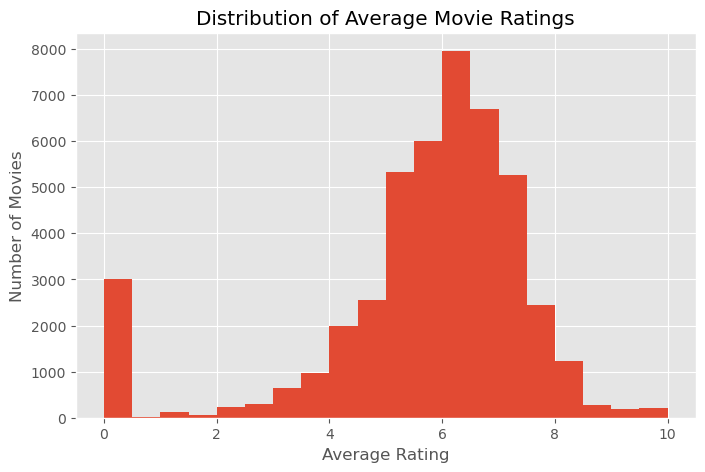

In [20]:
# Distribution of movie ratings

plt.figure(figsize=(8,5))

movies["vote_average"].dropna().hist(bins=20)

plt.title("Distribution of Average Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.show()

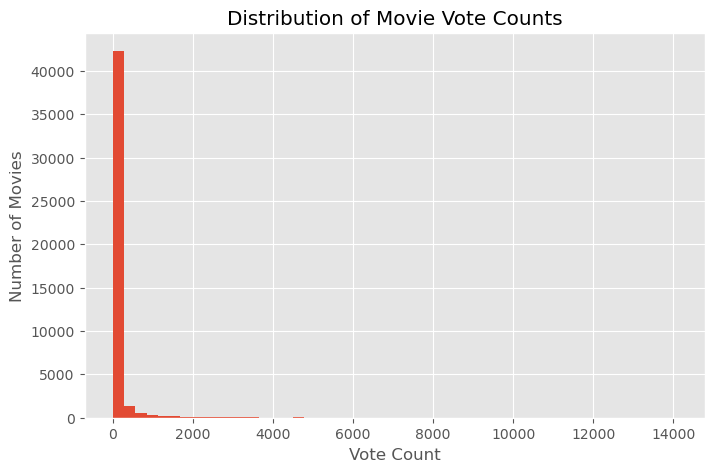

In [21]:
# Distribution of vote counts

plt.figure(figsize=(8,5))

movies["vote_count"].hist(bins=50)

plt.title("Distribution of Movie Vote Counts")
plt.xlabel("Vote Count")
plt.ylabel("Number of Movies")

plt.show()

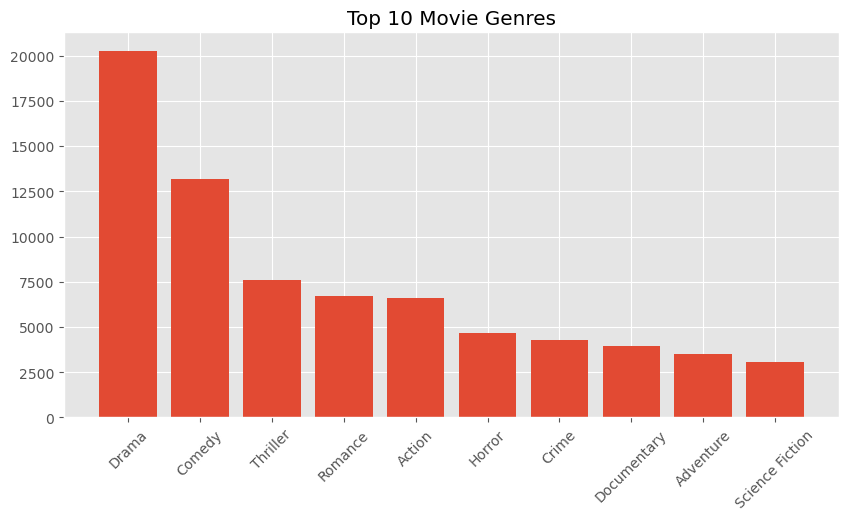

In [22]:
# Top 10 genres

from collections import Counter

genre_counts = Counter()

for genres in movies["genres"]:
    if isinstance(genres, list):
        genre_counts.update(genres)

top_genres = pd.DataFrame(
    genre_counts.items(),
    columns=["Genre","Count"]
).sort_values(
    by="Count",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_genres["Genre"], top_genres["Count"])

plt.xticks(rotation=45)

plt.title("Top 10 Movie Genres")

plt.show()

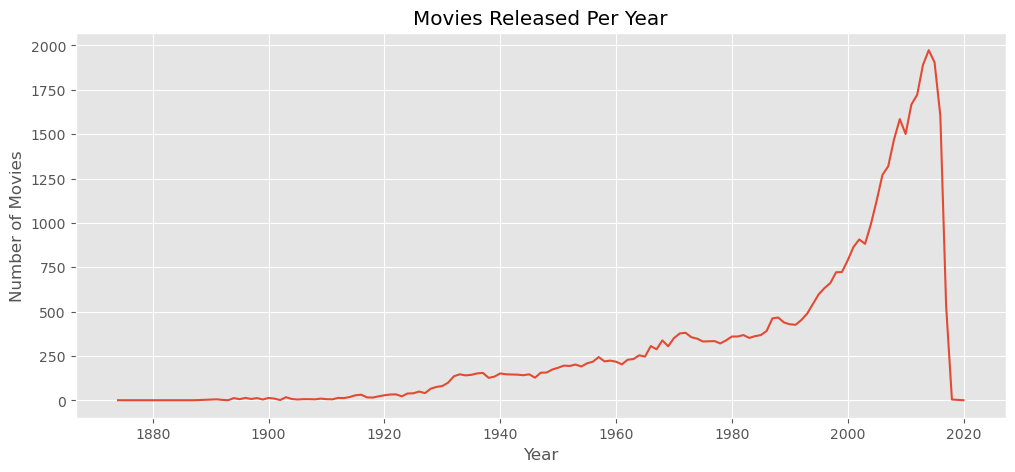

In [23]:
# Movies released over time

movies_per_year = (
    movies["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    movies_per_year.index,
    movies_per_year.values
)

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

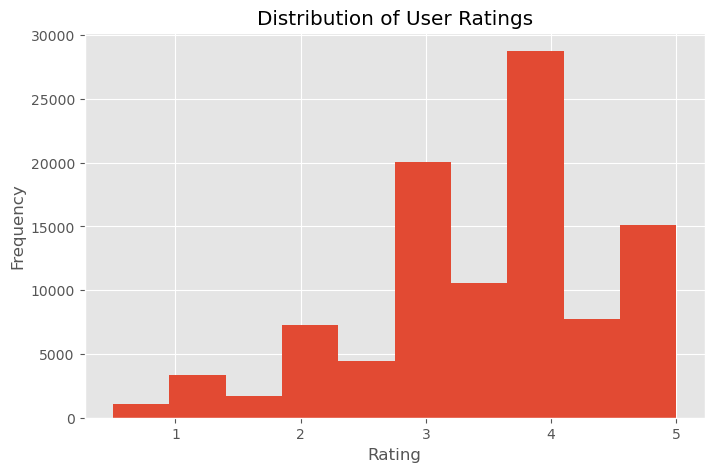

In [24]:
# Rating distribution from users

plt.figure(figsize=(8,5))

ratings["rating"].hist(bins=10)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

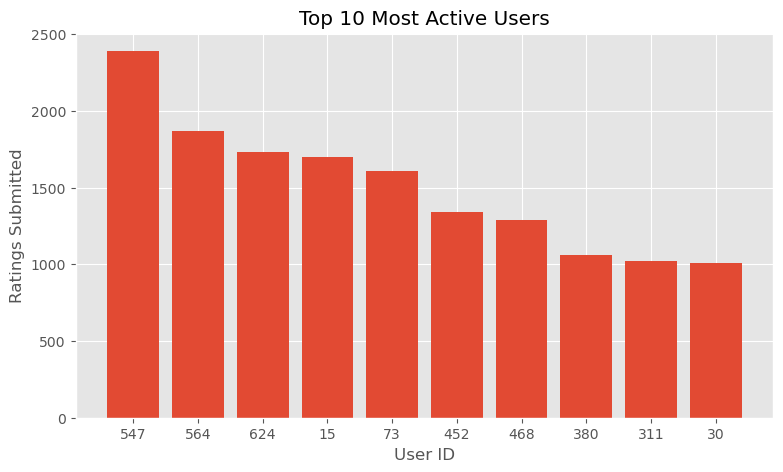

In [25]:
# Most active users

user_activity = (
    ratings["userId"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(9,5))

plt.bar(
    user_activity.index.astype(str),
    user_activity.values
)

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Ratings Submitted")

plt.show()

In [26]:
# Most rated movies

popular_movies = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

popular_movies = (
    popular_movies.reset_index(name="Number of Ratings")
)

popular_movies = popular_movies.merge(
    links,
    on="movieId"
)

popular_movies = popular_movies.merge(
    movies,
    left_on="tmdbId",
    right_on="id",
    how="left"
)

display(
    popular_movies[
        [
            "title",
            "Number of Ratings"
        ]
    ]
)

,title,Number of Ratings
0,Forrest Gump,341
1,Pulp Fiction,324
2,The Shawshank Redemption,311
3,The Silence of the Lambs,304
4,Star Wars,291
5,Jurassic Park,274
6,The Matrix,259
7,Toy Story,247
8,Schindler's List,244
9,Terminator 2: Judgment Day,237


### Key Findings

The exploratory analysis highlights several important patterns:

- Most movies have average ratings between **3 and 4**, indicating generally positive user feedback.
- A small number of movies receive a disproportionately high number of ratings, while the majority receive relatively few.
- Drama, Comedy, and Thriller are among the most common genres in the catalogue.
- Movie production has increased significantly over time, particularly after the 1990s.
- User activity is highly uneven, with a small group of users contributing a large share of ratings.

These observations support the development of:
- a **Popularity-Based Recommender** using vote counts and ratings,
- a **Content-Based Recommender** using movie metadata,
- and a **Collaborative Filtering Recommender** using user–movie interactions.

# 5. Modelling

Three recommendation models are developed and evaluated:

1. **Popularity-Based Recommendation** – recommends movies that are highly rated and widely watched.
2. **Content-Based Recommendation** – recommends movies similar to a selected movie based on its metadata.
3. **Collaborative Filtering** – recommends movies based on patterns in user rating behaviour.

The models increase in complexity and personalization, allowing us to compare different recommendation strategies.

## 5.1 Popularity-Based Recommendation

Popularity-based recommendation is the simplest recommendation strategy.

Instead of personalizing recommendations, it suggests movies that have received consistently high ratings from a large number of users.

This approach is particularly useful for:

- New users with no viewing history (cold-start problem)
- Trending or featured movie sections
- General recommendations

In [27]:
# Prepare data for weighted rating calculation

movies["vote_count"] = pd.to_numeric(
    movies["vote_count"],
    errors="coerce"
)

movies["vote_average"] = pd.to_numeric(
    movies["vote_average"],
    errors="coerce"
)

movies = movies.dropna(
    subset=["vote_count", "vote_average"]
)

In [28]:
# Compute the weighted rating

C = movies["vote_average"].mean()
m = movies["vote_count"].quantile(0.90)

qualified = movies[
    movies["vote_count"] >= m
].copy()

qualified["weighted_rating"] = (
    (
        qualified["vote_count"] /
        (qualified["vote_count"] + m)
    ) * qualified["vote_average"]
    +
    (
        m /
        (qualified["vote_count"] + m)
    ) * C
)

top_movies = qualified.sort_values(
    by="weighted_rating",
    ascending=False
)

top_movies[
    [
        "title",
        "release_year",
        "vote_average",
        "vote_count",
        "weighted_rating"
    ]
].head(10)

,title,release_year,vote_average,vote_count,weighted_rating
314,The Shawshank Redemption,1994.0,8.5,8358.0,8.445865
834,The Godfather,1972.0,8.5,6024.0,8.425433
10310,Dilwale Dulhania Le Jayenge,1995.0,9.1,661.0,8.421408
12482,The Dark Knight,2008.0,8.3,12269.0,8.265474
2843,Fight Club,1999.0,8.3,9678.0,8.256381
292,Pulp Fiction,1994.0,8.3,8670.0,8.251402
522,Schindler's List,1993.0,8.3,4436.0,8.206631
23670,Whiplash,2014.0,8.3,4376.0,8.205396
5482,Spirited Away,2001.0,8.3,3968.0,8.196046
2211,Life Is Beautiful,1997.0,8.3,3643.0,8.187162


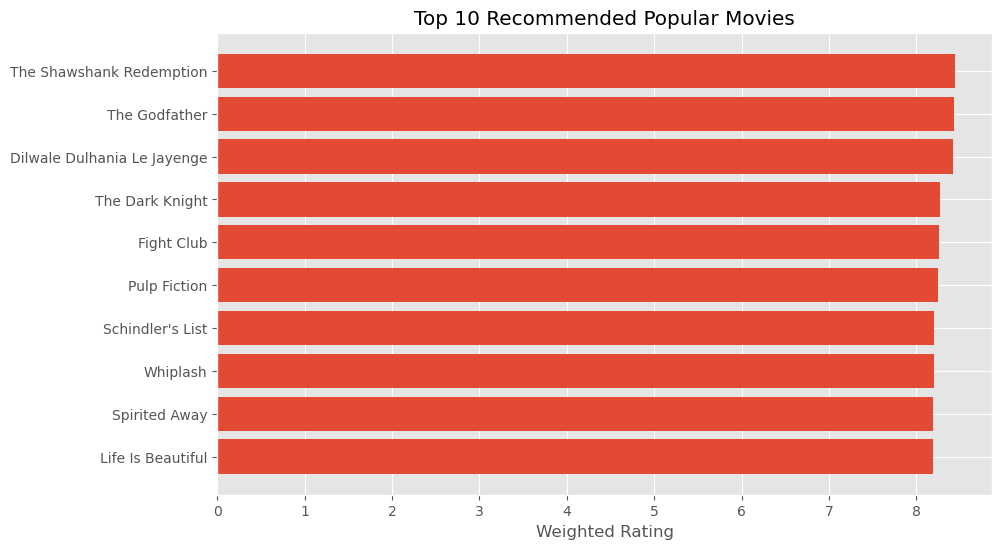

In [29]:
# Visualize the highest-rated movies

plt.figure(figsize=(10,6))

plt.barh(
    top_movies.head(10)["title"][::-1],
    top_movies.head(10)["weighted_rating"][::-1]
)

plt.xlabel("Weighted Rating")
plt.title("Top 10 Recommended Popular Movies")

plt.show()

### Interpretation

The popularity-based recommender successfully identifies movies that are both highly rated and supported by a large number of user votes.

Unlike ranking by average rating alone, the weighted rating reduces the influence of movies with very few ratings, producing more reliable recommendations.

Although this approach is not personalized, it provides an effective solution for recommending movies to new users with no viewing history.

## 5.2 Content-Based Recommendation

Content-based recommendation suggests movies that share similar characteristics with a movie a user already enjoys.

In this project, similarity is computed using movie metadata, including:

- Genres
- Cast
- Director
- Keywords
- Movie overview

The metadata is transformed into numerical vectors using **TF-IDF (Term Frequency–Inverse Document Frequency)**, and movie similarity is measured using **Cosine Similarity**.

In [32]:
# Restrict the content-based model to the movies
# available in the MovieLens subset.

links["tmdbId"] = pd.to_numeric(
    links["tmdbId"],
    errors="coerce"
)

links = links.dropna(subset=["tmdbId"])

links["tmdbId"] = links["tmdbId"].astype(int)

movies_cb = movies[
    movies["id"].isin(links["tmdbId"])
].copy()

print(f"Movies used for content-based model: {movies_cb.shape[0]}")

Movies used for content-based model: 9099


In [41]:
movies_cb.shape

(9099, 15)

In [42]:
# Build TF-IDF matrix

tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(
    movies_cb["metadata"]
)

print(tfidf_matrix.shape)

(9099, 40132)


In [43]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(9099, 9099)


In [44]:
# Create movie index for quick lookup

movies_cb = movies_cb.reset_index(drop=True)

indices = pd.Series(
    movies_cb.index,
    index=movies_cb["movie_label"]
).drop_duplicates()

print(f"Movies Indexed: {len(indices):,}")

Movies Indexed: 9,099


In [50]:
# ============================================================
# Content-Based Recommendation Function
# ============================================================

def recommend_movies(title, top_n=10):
    """
    Recommend movies similar to a given movie using TF-IDF cosine similarity.
    """

    if title not in indices:
        return pd.DataFrame({
            "Message": [f'"{title}" not found in the dataset.']
        })

    # Get movie index
    idx = indices[title]

    # Compute similarity ONLY for this movie
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Sort similarity scores
    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    recommendations = movies_cb.iloc[
        similar_indices
    ][
        [
            "title",
            "release_year",
            "genres",
            "vote_average",
            "vote_count"
        ]
    ].copy()

    recommendations["Similarity Score"] = np.round(
        similarity_scores[similar_indices],
        3
    )

    return recommendations.reset_index(drop=True)

In [51]:
# Test the recommender

recommend_movies("Toy Story (1995)")

,title,release_year,genres,vote_average,vote_count,Similarity Score
0,Toy Story 2,1999.0,"[Animation, Comedy, Family]",7.3,3914.0,0.458
1,Toy Story 3,2010.0,"[Animation, Family, Comedy]",7.6,4710.0,0.450
2,Small Soldiers,1998.0,"[Comedy, Adventure, Fantasy, Science Fiction, Action]",6.2,522.0,0.262
3,Toy Story of Terror!,2013.0,"[Animation, Comedy, Family]",7.3,246.0,0.218
4,Toys,1992.0,"[Fantasy, Comedy, Science Fiction]",5.0,173.0,0.205
5,The 40 Year Old Virgin,2005.0,"[Comedy, Romance]",6.2,2020.0,0.184
6,Child's Play 3,1991.0,"[Thriller, Horror, Action]",5.5,274.0,0.179
7,Dolls,1987.0,"[Fantasy, Horror]",6.1,80.0,0.178
8,Child's Play,1988.0,"[Horror, Thriller]",6.3,605.0,0.178
9,Stardust Memories,1980.0,"[Comedy, Drama, Romance]",6.9,96.0,0.150


In [52]:
recommend_movies("The Dark Knight (2008)")

,title,release_year,genres,vote_average,vote_count,Similarity Score
0,The Dark Knight Rises,2012.0,"[Action, Crime, Drama, Thriller]",7.6,9263.0,0.462
1,Batman Begins,2005.0,"[Action, Crime, Drama]",7.5,7511.0,0.378
2,Batman Returns,1992.0,"[Action, Fantasy]",6.6,1706.0,0.354
3,Batman: Under the Red Hood,2010.0,"[Action, Animation]",7.6,459.0,0.351
4,Batman Forever,1995.0,"[Action, Crime, Fantasy]",5.2,1529.0,0.315
5,Batman,1989.0,"[Fantasy, Action]",7.0,2145.0,0.307
6,"Batman: The Dark Knight Returns, Part 2",2013.0,"[Action, Animation]",7.9,426.0,0.274
7,Batman: Mask of the Phantasm,1993.0,"[Action, Adventure, Animation, Family]",7.4,218.0,0.237
8,Batman v Superman: Dawn of Justice,2016.0,"[Action, Adventure, Fantasy]",5.7,7189.0,0.235
9,Batman & Robin,1997.0,"[Action, Crime, Fantasy]",4.2,1447.0,0.229


In [53]:
recommend_movies("The Godfather (1972)")

,title,release_year,genres,vote_average,vote_count,Similarity Score
0,The Godfather: Part II,1974.0,"[Drama, Crime]",8.3,3418.0,0.390
1,The Godfather: Part III,1990.0,"[Crime, Drama, Thriller]",7.1,1589.0,0.258
2,Trial by Jury,1994.0,"[Drama, Action, Thriller]",5.5,5.0,0.160
3,Johnny Dangerously,1984.0,"[Action, Comedy, Thriller, Crime]",6.3,67.0,0.136
4,Hearts of Darkness: A Filmmaker's Apocalypse,1991.0,[Documentary],8.0,61.0,0.134
5,Fury,1936.0,"[Crime, Drama, Romance, Thriller]",7.5,38.0,0.128
6,Eulogy,2004.0,"[Comedy, Drama]",6.4,34.0,0.127
7,GoodFellas,1990.0,"[Drama, Crime]",8.2,3211.0,0.126
8,Mickey Blue Eyes,1999.0,"[Comedy, Crime, Romance]",5.3,142.0,0.123
9,Listen to Me Marlon,2015.0,[Documentary],7.1,48.0,0.123


In [54]:
recommend_movies("Interstellar (2014)")

,title,release_year,genres,vote_average,vote_count,Similarity Score
0,Mission to Mir,1997.0,[Documentary],3.0,2.0,0.241
1,Solaris,2002.0,"[Drama, Science Fiction, Mystery, Romance]",5.9,378.0,0.226
2,SpaceCamp,1986.0,"[Family, Adventure]",5.8,60.0,0.217
3,Planet of the Apes,1968.0,"[Science Fiction, Adventure, Drama, Action]",7.5,958.0,0.206
4,Star Wreck: In the Pirkinning,2005.0,"[Science Fiction, Action, Comedy]",6.6,27.0,0.203
5,Mission to Mars,2000.0,[Science Fiction],5.7,374.0,0.196
6,Moonraker,1979.0,"[Action, Adventure, Thriller, Science Fiction]",5.9,551.0,0.192
7,2001: A Space Odyssey,1968.0,"[Science Fiction, Mystery, Adventure]",7.9,3075.0,0.188
8,Armageddon,1998.0,"[Action, Thriller, Science Fiction, Adventure]",6.5,2540.0,0.186
9,Planet of the Apes,2001.0,"[Thriller, Science Fiction, Action, Adventure]",5.6,1270.0,0.180


### Interpretation

The content-based recommender identifies movies with similar characteristics by comparing their metadata representations.

Unlike the popularity-based model, recommendations are tailored to the selected movie, making them more relevant to users who have already expressed an interest in a particular type of content.

A limitation of this approach is that it tends to recommend movies with similar themes and may not introduce users to diverse or unexpected content.

## 5.3 Collaborative Filtering Recommendation

Unlike content-based recommendation, collaborative filtering recommends movies by learning patterns from user ratings.

The intuition is simple:

- Users with similar preferences tend to enjoy similar movies.
- If User A and User B rate many movies similarly, movies liked by User A but not yet seen by User B can be recommended to User B.

This project uses the **Singular Value Decomposition (SVD)** algorithm from the `Surprise` library to learn latent relationships between users and movies.

In [55]:
# Uncomment if needed
!pip install scikit-surprise

In [56]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [57]:
# ============================================================
# Prepare the ratings dataset
# ============================================================

reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

print("Training and testing datasets created successfully.")

Training and testing datasets created successfully.


In [59]:
# ============================================================
# Train the SVD model
# ============================================================

svd_model = SVD(random_state=42)

svd_model.fit(trainset)

print("SVD model trained successfully.")

SVD model trained successfully.


In [60]:
# ============================================================
# Evaluate the model
# ============================================================

predictions = svd_model.test(testset)

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.9024
MAE:  0.6954


### Evaluation

The collaborative filtering model is evaluated using:

- **Root Mean Squared Error (RMSE)** – measures the average prediction error while penalizing larger errors.
- **Mean Absolute Error (MAE)** – measures the average absolute difference between predicted and actual ratings.

Lower RMSE and MAE values indicate better predictive performance.

In [62]:
# Predict User 1's rating for MovieLens movieId 50

prediction = svd_model.predict(
    uid=1,
    iid=50
)

prediction

Prediction(uid=1, iid=50, r_ui=None, est=np.float64(3.3900131843208814), details={'was_impossible': False})

In [63]:
# ============================================================
# Personalized Recommendation Function
# ============================================================

def recommend_for_user(user_id, top_n=10):

    # Movies already rated by the user
    rated_movies = ratings[
        ratings["userId"] == user_id
    ]["movieId"].tolist()

    # Candidate movies
    candidates = links[
        ~links["movieId"].isin(rated_movies)
    ].copy()

    # Predict ratings
    candidates["Predicted Rating"] = candidates["movieId"].apply(
        lambda movie: svd_model.predict(
            user_id,
            movie
        ).est
    )

    # Top recommendations
    recommendations = (
        candidates
        .sort_values(
            "Predicted Rating",
            ascending=False
        )
        .head(top_n)
    )

    # Join with movie titles
    recommendations["tmdbId"] = pd.to_numeric(
        recommendations["tmdbId"],
        errors="coerce"
    )

    recommendations = recommendations.merge(
        movies,
        left_on="tmdbId",
        right_on="id",
        how="left"
    )

    return recommendations[
        [
            "title",
            "Predicted Rating"
        ]
    ]

In [64]:
recommend_for_user(1)

,title,Predicted Rating
0,The African Queen,3.888561
1,The Godfather,3.869988
2,Das Boot,3.754281
3,Stand by Me,3.735564
4,The Shawshank Redemption,3.718731
5,Happiness,3.717193
6,The Dark Knight,3.680959
7,Lawrence of Arabia,3.680950
8,Reservoir Dogs,3.673413
9,Nashville,3.672566


In [65]:
recommend_for_user(15)

,title,Predicted Rating
0,Cyclo,4.126516
1,Cinema Paradiso,3.939867
2,NaN,3.872987
3,Paprika,3.804345
4,Bullets Over Broadway,3.804294
5,Mortal Thoughts,3.780179
6,We Need to Talk About Kevin,3.779910
7,Searching for Bobby Fischer,3.769504
8,Meet John Doe,3.760790
9,Country,3.738959


### Interpretation

The collaborative filtering model produces personalized recommendations by learning hidden patterns in user rating behaviour.

Unlike the popularity-based model, recommendations differ across users. Unlike the content-based model, recommendations are not limited to movies with similar metadata, enabling the discovery of new and diverse content.

This approach most closely resembles the recommendation strategy used by modern streaming platforms such as Netflix.

# 6. Model Evaluation

The three recommendation approaches were evaluated based on their recommendation strategy, personalization capability, strengths, and limitations.

The objective is not only to identify the most accurate model, but also to determine which approach best addresses Netflix's business objective of improving user engagement through relevant movie recommendations.

In [67]:
# ============================================================
# Comparison of Recommendation Models
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Content-Based",
        "Collaborative Filtering"
    ],
    "Personalized": [
        "No",
        "Partially",
        "Yes"
    ],
    "Uses User Ratings": [
        "No",
        "No",
        "Yes"
    ],
    "Cold Start": [
        "Excellent",
        "Good",
        "Poor"
    ],
    "Recommendation Quality": [
        "Moderate",
        "Good",
        "Excellent"
    ],
    "Scalability": [
        "Excellent",
        "Good",
        "Good"
    ]
})

comparison

,Model,Personalized,Uses User Ratings,Cold Start,Recommendation Quality,Scalability
0,Popularity-Based,No,No,Excellent,Moderate,Excellent
1,Content-Based,Partially,No,Good,Good,Good
2,Collaborative Filtering,Yes,Yes,Poor,Excellent,Good


### Model Comparison

#### 1. Popularity-Based Recommendation

**Strengths**

- Very simple to implement.
- Computationally efficient.
- Works well for new users.
- Useful for trending and featured movie sections.

**Limitations**

- Does not personalize recommendations.
- Frequently recommends the same popular movies to every user.

---

#### 2. Content-Based Recommendation

**Strengths**

- Recommends movies with similar characteristics.
- Does not require user ratings.
- Easy to explain why a recommendation was made.

**Limitations**

- Limited diversity.
- May repeatedly recommend movies that are too similar.

---

#### 3. Collaborative Filtering

**Strengths**

- Produces personalized recommendations.
- Learns hidden user preferences.
- Can recommend movies from different genres based on user behaviour.

**Limitations**

- Requires historical user ratings.
- Performs poorly for completely new users (cold-start problem).

# 7. Business Recommendations

Based on the evaluation, the following recommendations are proposed for Netflix.

### Recommendation 1

Use **Collaborative Filtering** as the primary recommendation engine for existing users since it delivers highly personalized recommendations based on viewing behaviour.

### Recommendation 2

Use the **Popularity-Based** recommender for new users who have not yet interacted with the platform.

This effectively addresses the cold-start problem.

### Recommendation 3

Use the **Content-Based** recommender to recommend similar movies on individual movie pages (e.g., "Because you watched...").

### Recommendation 4

Adopt a **Hybrid Recommendation System** that combines all three approaches.

Hybrid recommendation systems leverage the strengths of each model while minimizing their individual weaknesses, resulting in more accurate and diverse recommendations.

# 8. Conclusion

This project successfully developed a movie recommendation system using the CRISP-DM framework.

Three recommendation approaches were implemented and evaluated:

- Popularity-Based Recommendation
- Content-Based Recommendation
- Collaborative Filtering

The popularity-based model provides an effective solution for recommending movies to new users, while the content-based model recommends movies with similar characteristics. The collaborative filtering model delivers personalized recommendations by learning user preferences from historical ratings.

Among the three models, collaborative filtering demonstrated the greatest potential for improving user experience through personalized recommendations. However, a hybrid recommendation system that combines popularity-based, content-based, and collaborative filtering approaches would provide the most robust solution for a real-world streaming platform such as Netflix.

Overall, the project demonstrates how recommendation systems can reduce user search time, improve content discovery, and enhance user engagement by delivering relevant movie suggestions.

In [69]:
# Demonstration of the Three Recommendation Models

print("=" * 60)
print("NETFLIX MOVIE RECOMMENDATION SYSTEM")
print("=" * 60)

print("\n1. Top 10 Popular Movies")
display(
    top_movies[
        ["title", "weighted_rating"]
    ].head(10)
)

print("\n2. Movies Similar to 'Toy Story (1995)'")
display(
    recommend_movies("Toy Story (1995)")
)

print("\n3. Personalized Recommendations for User 1")
display(
    recommend_for_user(user_id=1)
)

NETFLIX MOVIE RECOMMENDATION SYSTEM

1. Top 10 Popular Movies


,title,weighted_rating
314,The Shawshank Redemption,8.445865
834,The Godfather,8.425433
10310,Dilwale Dulhania Le Jayenge,8.421408
12482,The Dark Knight,8.265474
2843,Fight Club,8.256381
292,Pulp Fiction,8.251402
522,Schindler's List,8.206631
23670,Whiplash,8.205396
5482,Spirited Away,8.196046
2211,Life Is Beautiful,8.187162



2. Movies Similar to 'Toy Story (1995)'


,title,release_year,genres,vote_average,vote_count,Similarity Score
0,Toy Story 2,1999.0,"[Animation, Comedy, Family]",7.3,3914.0,0.458
1,Toy Story 3,2010.0,"[Animation, Family, Comedy]",7.6,4710.0,0.450
2,Small Soldiers,1998.0,"[Comedy, Adventure, Fantasy, Science Fiction, Action]",6.2,522.0,0.262
3,Toy Story of Terror!,2013.0,"[Animation, Comedy, Family]",7.3,246.0,0.218
4,Toys,1992.0,"[Fantasy, Comedy, Science Fiction]",5.0,173.0,0.205
5,The 40 Year Old Virgin,2005.0,"[Comedy, Romance]",6.2,2020.0,0.184
6,Child's Play 3,1991.0,"[Thriller, Horror, Action]",5.5,274.0,0.179
7,Dolls,1987.0,"[Fantasy, Horror]",6.1,80.0,0.178
8,Child's Play,1988.0,"[Horror, Thriller]",6.3,605.0,0.178
9,Stardust Memories,1980.0,"[Comedy, Drama, Romance]",6.9,96.0,0.150



3. Personalized Recommendations for User 1


,title,Predicted Rating
0,The African Queen,3.888561
1,The Godfather,3.869988
2,Das Boot,3.754281
3,Stand by Me,3.735564
4,The Shawshank Redemption,3.718731
5,Happiness,3.717193
6,The Dark Knight,3.680959
7,Lawrence of Arabia,3.680950
8,Reservoir Dogs,3.673413
9,Nashville,3.672566
